# Lab 01:  Introduction to Machine Learning in Python
---



## The Python ML Ecosystem 

Let's meet the main ML python library players.

---

### 📦 NumPy — The Foundation

Before the ML-specific packages, **NumPy** is the backbone everything else is built on. It provides fast, efficient **multi-dimensional arrays** (`ndarray`) and element-wise math operations.

Almost every ML library stores data as NumPy arrays under the hood.

### Example

In [38]:
import numpy as np

# Simulated daily weather readings from a forest monitoring station
temperatures = np.array([28.0, 32.5, 36.1, 29.8, 41.0, 38.3, 22.5, 35.7])
humidity     = np.array([57.0, 42.0, 33.0, 65.0, 18.0, 25.0, 78.0, 38.0])

print("Temperatures (C):", temperatures)
print("Mean temperature :", np.mean(temperatures).round(2))
print("Max temperature  :", np.max(temperatures))
print("Std deviation    :", np.std(temperatures).round(2))

# Operations apply element-wise — no loops needed!
# Rough heat-dryness index: higher = greater fire concern
heat_dryness = temperatures * (1 - humidity / 100)
print("\nHeat-dryness index:", np.round(heat_dryness, 2))

Temperatures (C): [28.  32.5 36.1 29.8 41.  38.3 22.5 35.7]
Mean temperature : 32.99
Max temperature  : 41.0
Std deviation    : 5.64

Heat-dryness index: [12.04 18.85 24.19 10.43 33.62 28.72  4.95 22.13]


<hr>
###  SciPy — Scientific Computing

**SciPy** builds on NumPy and provides algorithms for:
- Statistics (`scipy.stats`)
- Linear algebra (`scipy.linalg`)
- Optimization (`scipy.optimize`) — the math behind model training
- Spatial data and distances (`scipy.spatial`)

In ML, SciPy is used for **statistical tests**, **distance calculations**, and **preprocessing math**. Many scikit-learn functions use SciPy internally.

| Module | What it does |
|--------|--------------|
| `scipy.stats` | Distributions, hypothesis tests, normality checks |
| `scipy.spatial` | Distance metrics (Euclidean, cosine, etc.) |
| `scipy.sparse` | Sparse matrices — efficient storage for high-dimensional data |
| `scipy.optimize` | Minimization functions that power gradient descent |

In [39]:
import scipy.stats as stats
from scipy.spatial import distance
from scipy.spatial.distance import euclidean

# --- scipy.stats: Are fire-day temperatures statistically different? ---
fire_temps    = np.array([38.5, 41.2, 36.8, 40.1, 39.5, 37.9, 42.0, 38.8])
no_fire_temps = np.array([22.1, 28.4, 25.6, 30.2, 19.8, 26.5, 23.0, 27.1])

t_stat, p_value = stats.ttest_ind(fire_temps, no_fire_temps)

print("=== t-test: fire-day vs no-fire-day temperatures ===")
print(f"Fire mean   : {fire_temps.mean():.2f} C")
print(f"No-fire mean: {no_fire_temps.mean():.2f} C")
print(f"t-statistic : {t_stat:.3f}")
print(f"p-value     : {p_value:.6f}")
print(f"Significant : {'Yes - temperature is a strong predictor!' if p_value < 0.05 else 'No'}")

# --- scipy.spatial: distance between two weather observations ---
# Each observation: [Temperature, Humidity, Wind, Rain]
day_A = [35.0, 28.0, 15.0, 0.0]   # hot, dry, windy — fire likely
day_B = [22.0, 75.0,  5.0, 2.5]   # cool, humid, calm, rainy — fire unlikely

print(f"\nEuclidean distance between day A and day B: {euclidean(day_A, day_B):.2f}")
print("(Large distance = very different weather conditions)")

=== t-test: fire-day vs no-fire-day temperatures ===
Fire mean   : 39.35 C
No-fire mean: 25.34 C
t-statistic : 10.242
p-value     : 0.000000
Significant : Yes - temperature is a strong predictor!

Euclidean distance between day A and day B: 49.84
(Large distance = very different weather conditions)


<hr>
###  scikit-learn (sklearn): Machine Learning Library

**scikit-learn** is the go-to library for classical machine learning in Python. It provides:

- **Dozens of ready-to-use algorithms** (regression, decision trees, SVMs, k-means, etc.)
- **Consistent API** — every model has the same `.fit()`, `.predict()`, `.score()` methods
- **Preprocessing tools** — scaling, encoding, imputing missing values
- **Model evaluation** — cross-validation, metrics, confusion matrices
- **Pipelines** — chain preprocessing + modeling steps together cleanly

#### The sklearn API pattern — learn it once, use it everywhere:

```python
from sklearn.some_module import SomeModel

model = SomeModel()                    # 1. Create the model
model.fit(X_train, y_train)            # 2. Train it on data
predictions = model.predict(X_test)    # 3. Make predictions
score = model.score(X_test, y_test)    # 4. Evaluate it
```

This same 4-step pattern works for **every** sklearn algorithm.



| Module | What it provides |
|--------|-----------------|
| `sklearn.linear_model` | Linear & Logistic Regression |
| `sklearn.tree` | Decision Trees |
| `sklearn.ensemble` | Random Forests, Gradient Boosting |
| `sklearn.svm` | Support Vector Machines |
| `sklearn.neighbors` | K-Nearest Neighbors |
| `sklearn.cluster` | K-Means, DBSCAN (unsupervised) |
| `sklearn.preprocessing` | Scaling, Encoding, Normalization |
| `sklearn.model_selection` | train_test_split, cross_val_score |
| `sklearn.metrics` | Accuracy, F1, RMSE, Confusion Matrix |

<hr>
### statsmodels: Statistical Inference Library

**statsmodels** is the go-to library for statistical analysis and inference in Python. While sklearn focuses on *prediction*, statsmodels focuses on *understanding your data* — giving you the full picture of model diagnostics. It provides:

- **Detailed model summaries** — coefficients, p-values, t-statistics, confidence intervals
- **Hypothesis testing** — test whether a coefficient is statistically significant
- **Inference-first design** — built for answering "does X actually affect Y?" not just "what does Y predict?"
- **Wide range of models** — OLS, GLM, time series (ARIMA), logistic regression, and more
- **Residual diagnostics** — check assumptions like normality and homoscedasticity

#### The statsmodels pattern:

    import statsmodels.api as sm

    X_with_const = sm.add_constant(X)      # 1. Add intercept manually
    model = sm.OLS(y, X_with_const).fit()  # 2. Fit the model
    print(model.summary())                 # 3. Get the full stats breakdown

#### Key attributes after fitting:

| Attribute | What it gives you |
|-----------|------------------|
| `model.params` | Coefficients (like `coef_` in sklearn) |
| `model.pvalues` | P-values for each coefficient |
| `model.tvalues` | T-statistics |
| `model.bse` | Standard errors |
| `model.conf_int()` | 95% confidence intervals |
| `model.rsquared` | R² score |
| `model.summary()` | Full table with all of the above |


### statsmodels: Statistical Inference Library

**statsmodels** is the go-to library for statistical analysis and inference in Python. While sklearn focuses on *prediction*, statsmodels focuses on *understanding your data* — giving you the full picture of model diagnostics. It provides:

- **Detailed model summaries** — coefficients, p-values, t-statistics, confidence intervals
- **Hypothesis testing** — test whether a coefficient is statistically significant
- **Inference-first design** — built for answering "does X actually affect Y?" not just "what does Y predict?"
- **Wide range of models** — OLS, GLM, time series (ARIMA), logistic regression, and more
- **Residual diagnostics** — check assumptions like normality and homoscedasticity

#### The statsmodels pattern:
```python
import statsmodels.api as sm

X_with_const = sm.add_constant(X)      # 1. Add intercept manually
model = sm.OLS(y, X_with_const).fit()  # 2. Fit the model
print(model.summary())                 # 3. Get the full stats breakdown
```

#### Key attributes after fitting:

| Attribute | What it gives you |
|-----------|------------------|
| `model.params` | Coefficients (like `coef_` in sklearn) |
| `model.pvalues` | P-values for each coefficient |
| `model.tvalues` | T-statistics |
| `model.bse` | Standard errors |
| `model.conf_int()` | 95% confidence intervals |
| `model.rsquared` | R² score |
| `model.summary()` | Full table with all of the above |

#### sklearn vs statsmodels — when to use which:

| | sklearn | statsmodels |
|---|---|---|
| Goal | Predict on new data | Understand relationships in data |
| Output | Predictions, scores | Coefficients, p-values, diagnostics |
| Use when | Building an ML pipeline | Running a regression analysis |


### Ecosystem Summary

```
NumPy          ->  Arrays and math (the foundation of everything)
SciPy          ->  Scientific algorithms: stats, distances, optimization
Pandas         ->  Data manipulation and exploration
scikit-learn   ->  Classical ML models, preprocessing, evaluation
statsmodels    ->  Statistical Analysis and inference
```


### statsmodels: Statistical Inference Library

**statsmodels** is the go-to library for statistical analysis and inference in Python. While sklearn focuses on *prediction*, statsmodels focuses on *understanding your data* — giving you the full picture of model diagnostics. It provides:

- **Detailed model summaries** — coefficients, p-values, t-statistics, confidence intervals
- **Hypothesis testing** — test whether a coefficient is statistically significant
- **Inference-first design** — built for answering "does X actually affect Y?" not just "what does Y predict?"
- **Wide range of models** — OLS, GLM, time series (ARIMA), logistic regression, and more
- **Residual diagnostics** — check assumptions like normality and homoscedasticity

#### The statsmodels pattern:
```python
import statsmodels.api as sm

X_with_const = sm.add_constant(X)      # 1. Add intercept manually
model = sm.OLS(y, X_with_const).fit()  # 2. Fit the model
print(model.summary())                 # 3. Get the full stats breakdown
```

#### Key attributes after fitting:

| Attribute | What it gives you |
|-----------|------------------|
| `model.params` | Coefficients (like `coef_` in sklearn) |
| `model.pvalues` | P-values for each coefficient |
| `model.tvalues` | T-statistics |
| `model.bse` | Standard errors |
| `model.conf_int()` | 95% confidence intervals |
| `model.rsquared` | R² score |
| `model.summary()` | Full table with all of the above |

#### sklearn vs statsmodels — when to use which:

| | sklearn | statsmodels |
|---|---|---|
| Goal | Predict on new data | Understand relationships in data |
| Output | Predictions, scores | Coefficients, p-values, diagnostics |
| Use when | Building an ML pipeline | Running a regression analysis |


## Demo: The Algerian Forest Fires Dataset

We will use the **Algerian Forest Fires** dataset from the UCI Machine Learning Repository, fetched directly using the `ucimlrepo` package.

### Background

This dataset was collected across two regions of Algeria — **Bejaia** (northeast) and **Sidi Bel-Abbes** (northwest) — during the summer of 2012 (June to September). Researchers recorded daily weather conditions alongside fire danger indices.

### Predictor and Target

For this lab we'll fit a **simple linear regression** with one predictor:

| Variable | Role | Description |
|----------|------|-------------|
| `ISI` | Predictor (X) | Initial Spread Index — measures how fast a fire would spread based on wind and fuel moisture |
| `FWI` | Target (y) | Fire Weather Index — overall measure of fire danger |

These two are directly related in the Canadian Forest Fire Weather Index system: ISI feeds into the FWI calculation, so we expect a strong linear relationship.

This is a **supervised regression** problem: given X, learn f̂(X) = β₀ + β₁X that predicts FWI.

In [40]:
import numpy as np
import pandas as pd
from ucimlrepo import fetch_ucirepo

forest_fires = fetch_ucirepo(id=547)

df = forest_fires.data.features.reset_index(drop=True)

df

,region,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI
0,Bejaia,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5
1,Bejaia,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4
2,Bejaia,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1
3,Bejaia,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0
4,Bejaia,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,Sidi-Bel Abbes,26,9,2012,30,65,14,0.0,85.4,16.0,44.5,4.5,16.9,6.5
240,Sidi-Bel Abbes,27,9,2012,28,87,15,4.4,41.1,6.5,8,0.1,6.2,0
241,Sidi-Bel Abbes,28,9,2012,27,87,29,0.5,45.9,3.5,7.9,0.4,3.4,0.2
242,Sidi-Bel Abbes,29,9,2012,24,54,18,0.1,79.7,4.3,15.2,1.7,5.1,0.7


<hr>
## Data Cleaning

This dataset has two main messy features we need to update before we can build our model/ visualizations. 

1. **Whitespace in column names** — some column names have trailing spaces that will cause silent lookup errors
2. **One corrupted row** — a data entry error packed two values into one cell, which will surface as `NaN` after we convert columns to numeric

### Step 1: Strip whitespace from column names

In [41]:

print("Column names before cleaning:", df.columns.tolist())

df.columns = df.columns.str.strip()

print("Column names after cleaning:", df.columns.tolist())

Column names before cleaning: ['region', 'day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI']
Column names after cleaning: ['region', 'day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI']


### Step 2: Convert columns to numeric dtypes

Row 165 has a data entry error where two values were merged into one cell (e.g., `DC = "14.6 9"`). Pandas read the affected columns (`DC`, `FWI`) as strings instead of numbers. Converting to numeric with `errors='coerce'` turns that bad value into `NaN`, making the corrupted row easy to identify and remove.

In [42]:

print("DC and FWI Column types before conversion: ")
print(df[['DC', 'FWI']].dtypes)




DC and FWI Column types before conversion: 
DC     object
FWI    object
dtype: object


In [43]:
numeric_cols = [c for c in df.columns if c != 'region']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

print("DC and FWI Column types after conversion: ")
print(df[['DC', 'FWI']].dtypes)

DC and FWI Column types after conversion: 
DC     float64
FWI    float64
dtype: object


### Step 3: Drop rows with missing values

Any row with a `NaN` is unusable for modeling. Dropping them removes the one corrupted row identified above.

In [44]:
df = df.dropna().reset_index(drop=True)

print(df.dtypes)

region          object
day              int64
month            int64
year             int64
Temperature      int64
RH               int64
Ws               int64
Rain           float64
FFMC           float64
DMC            float64
DC             float64
ISI            float64
BUI            float64
FWI            float64
dtype: object


<hr>
### Exploratory Data Analysis

Before modeling, let's look at the distribution of our target variable and the relationship between our predictor and target.

Two plots below:
1. **FWI distribution** — what does the range of fire danger look like?
2. **ISI vs. FWI** — does a higher initial spread index correspond to higher overall fire danger?

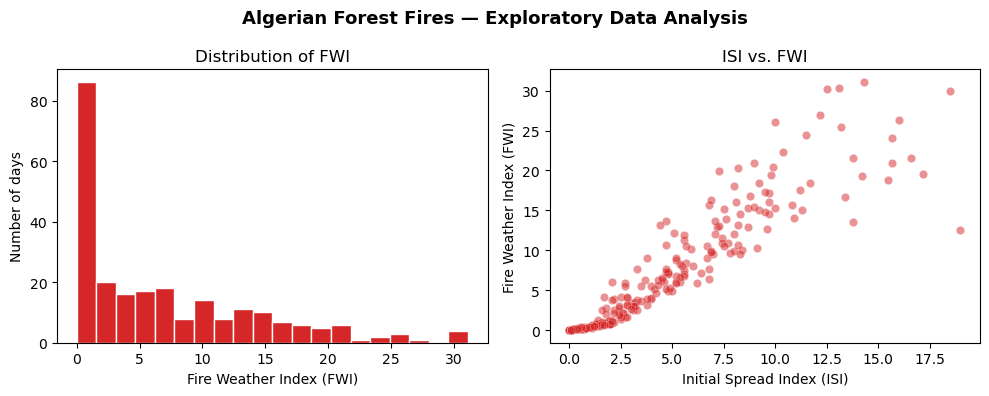

In [45]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- Plot 1: FWI distribution ---
axes[0].hist(df['FWI'], bins=20, color='#d62728', edgecolor='white')
axes[0].set_xlabel('Fire Weather Index (FWI)')
axes[0].set_ylabel('Number of days')
axes[0].set_title('Distribution of FWI')

# --- Plot 2: ISI vs FWI ---
axes[1].scatter(df['ISI'], df['FWI'], alpha=0.5, color='#d62728', edgecolor='white', linewidths=0.3)
axes[1].set_xlabel('Initial Spread Index (ISI)')
axes[1].set_ylabel('Fire Weather Index (FWI)')
axes[1].set_title('ISI vs. FWI')

plt.suptitle('Algerian Forest Fires — Exploratory Data Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<hr>
## Preparing X and y

Extract the single predictor (`ISI`) and the target (`FWI`) from `df`. sklearn expects X to be **2D** — even for a single feature — so we use double brackets `df[['ISI']]` to get a one-column DataFrame rather than a flat array.

In [46]:
X = df[['ISI']].values   # shape (n, 1) — 2D required by sklearn
y = df['FWI'].values     # shape (n,)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (243, 1)
y shape: (243,)


<hr>
## Training vs. Testing: The Core Concept

Before fitting a model, we split our data into two non-overlapping sets:

```
All Data (243 days)
|
|-- Training Set (80% = ~194 days)   <-- model learns from this
|
|-- Test Set     (20% = ~49 days)    <-- model is evaluated on this
```

**Why?** We want to know how the model performs on data it has never seen — that's what matters in practice. Evaluating on the same data used for training gives an overly optimistic picture.

After fitting on the training set, we'll compare R² on both sets. For a well-behaved model like linear regression, the two should be close — confirming that the model generalizes rather than just fitting noise.

<hr>
## `train_test_split` in Depth

scikit-learn provides `train_test_split` to split data automatically and safely.

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,            # feature matrix
    y,            # target vector
    test_size,    # fraction or count to put in the test set
    random_state  # integer seed for reproducibility
)
```

Let's dig into each parameter.

### `random_state`

`train_test_split` randomly shuffles the data before splitting. That is good — you don't want all fire days landing in the training set.

But random shuffling means a **different split every run**, making results impossible to reproduce or compare. `random_state` sets a fixed random seed so the split is identical every time.

- `random_state=42` — any integer; 42 is common convention
- `random_state=None` — truly random every run (not reproducible)

### `stratify`

For **classification** problems, `train_test_split` accepts a `stratify=y` argument that preserves class proportions in both splits. For **regression**, there are no discrete classes, so `stratify` is not applicable — the split is always random.

### `test_size`

`test_size` accepts:
- A **float** between 0 and 1 — proportion of data (e.g. `0.2` = 20%)
- An **integer** — exact number of samples (e.g. `50` = 50 days)

| Split | Train % | Test % | Best for |
|-------|---------|--------|---------|
| 80/20 | 80 | 20 | Default; works well for most datasets |
| 70/30 | 70 | 30 | Smaller datasets needing more test coverage |
| 90/10 | 90 | 10 | Large datasets where training data is precious |

Rule of thumb: more training data means a better model, but you need at least 30-50 test samples for a reliable evaluation.

### How Test Size Affects Model Performance

Choosing `test_size` involves a tradeoff:

- **Smaller test set** → more data for training → higher train accuracy, but the test estimate is based on fewer samples and is less reliable (higher variance across different random splits)
- **Larger test set** → more reliable performance estimate, but the model trains on less data


### An Example

In [47]:
from sklearn.model_selection import train_test_split

# Standard 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,    # 20% goes to test set
    random_state=42   # fix the random seed
)

print(f"Original dataset : {X.shape[0]} observations")
print()
print("Training set:")
print(f"  X_train: {X_train.shape}  -> {len(X_train)} days")
print(f"  y_train: {y_train.shape}")
print()
print("Test set:")
print(f"  X_test : {X_test.shape}   -> {len(X_test)} days")
print(f"  y_test : {y_test.shape}")

Original dataset : 243 observations

Training set:
  X_train: (194, 1)  -> 194 days
  y_train: (194,)

Test set:
  X_test : (49, 1)   -> 49 days
  y_test : (49,)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"Test R²: {r2_score(y_test, y_pred):.3f}")



Test R²: 0.897
